# Exp 3: Image Backbone Selection — ResNet50 vs ViT + DistilBERT + Concat + MLP

**Goal:** Find the best image backbone for multimodal fusion.

**Hyperparameters:** Auto-loaded per backbone from `results/tuning/exp3_{backbone}_best_params.json`.

**Pipeline:**
```
Image [D_img] → Linear(D_img, proj_dim) → GELU → Dropout ─┐
                                                            ├→ Concat → MLP → 1
Text  [768]   → Linear(768,  proj_dim)  → GELU → Dropout ─┘
```

In [1]:
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import json, os, copy
import warnings

warnings.filterwarnings('ignore')

ROOT = Path("../..").parent.resolve()
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'Root path: {ROOT}')

Using device: mps
Root path: /Users/shrutisivakumar/Library/CloudStorage/OneDrive-Personal/College Stuff/Sem 6/Projects/NLP/Facebook-Hateful-Memes-Challenge-2020


## 1. Load Embeddings

In [12]:
IMG_DIR  = ROOT / 'artifacts/embeddings/image'
TEXT_DIR = ROOT / 'artifacts/embeddings/text'
IMG_DIMS = {'resnet50': 2048, 'vit': 768}

raw = {}
for img_key in ['resnet50', 'vit']:
    Xi_tr = np.load(IMG_DIR  / f'train_{img_key}.npy').astype(np.float32)
    Xt_tr = np.load(TEXT_DIR / 'train_distilbert.npy').astype(np.float32)
    y_tr  = np.load(IMG_DIR  / 'train_labels.npy')
    Xi_dv = np.load(IMG_DIR  / f'dev_{img_key}.npy').astype(np.float32)
    Xt_dv = np.load(TEXT_DIR / 'dev_distilbert.npy').astype(np.float32)
    y_dv  = np.load(IMG_DIR  / 'dev_labels.npy')
    sci   = StandardScaler().fit(Xi_tr)
    sct   = StandardScaler().fit(Xt_tr)
    raw[img_key] = (sci.transform(Xi_tr), sct.transform(Xt_tr), y_tr,
                    sci.transform(Xi_dv), sct.transform(Xt_dv), y_dv)
    print(f'{img_key}: img={Xi_tr.shape}, text={Xt_tr.shape}')

y_train  = raw['resnet50'][2]
n_pos    = (y_train == 1).sum()
n_neg    = (y_train == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f'pos_weight: {pos_weight.item():.3f}')

resnet50: img=(8500, 2048), text=(8500, 768)
vit: img=(8500, 768), text=(8500, 768)
pos_weight: 1.787


## 2. Load Tuned Hyperparameters (per backbone)

In [13]:
DEFAULTS = {'proj_dim': 256, 'hidden1': 128, 'hidden2': 32,
            'dropout_proj': 0.3, 'dropout1': 0.3, 'dropout2': 0.2,
            'lr': 1e-4, 'weight_decay': 1e-3}

tuned_params = {}
for img_key in ['resnet50', 'vit']:
    path = ROOT / f'results/tuning/exp3_{img_key}_best_params.json'
    if path.exists():
        tuned_params[img_key] = json.load(open(path))['params']
        print(f'{img_key}: loaded tuned params → {tuned_params[img_key]}')
    else:
        tuned_params[img_key] = DEFAULTS.copy()
        print(f'{img_key}: tuning not found — using defaults')

resnet50: loaded tuned params → {'proj_dim': 512, 'hidden1': 256, 'hidden2': 16, 'dropout_proj': 0.12930163420191518, 'dropout1': 0.4052699079536471, 'dropout2': 0.23204574812188042, 'lr': 0.000161190447276092, 'weight_decay': 0.0003058656666978527}
vit: loaded tuned params → {'proj_dim': 512, 'hidden1': 64, 'hidden2': 16, 'dropout_proj': 0.3119673709739203, 'dropout1': 0.3231939855156805, 'dropout2': 0.17305300348035824, 'lr': 0.0002623436007711755, 'weight_decay': 1.1443137160728232e-05}


## 3. DataLoader Factory

In [14]:
BATCH_SIZE = 64

def make_loader(Xi, Xt, y, shuffle=False):
    ds = TensorDataset(torch.tensor(Xi, dtype=torch.float32),
                       torch.tensor(Xt, dtype=torch.float32),
                       torch.tensor(y,  dtype=torch.float32))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

loaders = {}
for img_key in ['resnet50', 'vit']:
    Xi_tr, Xt_tr, y_tr, Xi_dv, Xt_dv, y_dv = raw[img_key]
    loaders[img_key] = {
        'train': make_loader(Xi_tr, Xt_tr, y_tr, shuffle=True),
        'dev':   make_loader(Xi_dv, Xt_dv, y_dv)
    }
print('DataLoaders ready.')

DataLoaders ready.


## 4. Model

In [15]:
class ProjectionFusionMLP(nn.Module):
    def __init__(self, img_dim, text_dim=768, proj_dim=256,
                 d_proj=0.3, h1=128, h2=32, d1=0.3, d2=0.2):
        super().__init__()
        self.img_proj  = nn.Sequential(nn.Linear(img_dim,  proj_dim), nn.GELU(), nn.Dropout(d_proj))
        self.text_proj = nn.Sequential(nn.Linear(text_dim, proj_dim), nn.GELU(), nn.Dropout(d_proj))
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim * 2, h1), nn.LayerNorm(h1), nn.GELU(), nn.Dropout(d1),
            nn.Linear(h1, h2),           nn.LayerNorm(h2), nn.GELU(), nn.Dropout(d2),
            nn.Linear(h2, 1)
        )
    def forward(self, x_img, x_text):
        return self.classifier(
            torch.cat([self.img_proj(x_img), self.text_proj(x_text)], dim=-1)
        ).squeeze(-1)

## 5. Train & Evaluate

In [16]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_probs, all_labels = 0, [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x_img, x_text, y in loader:
            x_img, x_text, y = x_img.to(DEVICE), x_text.to(DEVICE), y.to(DEVICE)
            logits = model(x_img, x_text)
            loss   = criterion(logits, y)
            if is_train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, (np.array(all_probs) >= 0.5).astype(int))
    return total_loss / len(all_labels), auc, acc, np.array(all_probs), np.array(all_labels)


def train_model(img_key, epochs=50, patience=10):
    p = tuned_params[img_key]
    print(f'\n{"="*55}')
    print(f'Training: {img_key.upper()} + DistilBERT | params: {p}')
    print(f'{"="*55}')

    model = ProjectionFusionMLP(
        img_dim=IMG_DIMS[img_key], proj_dim=p['proj_dim'],
        d_proj=p['dropout_proj'], h1=p['hidden1'], h2=p['hidden2'],
        d1=p['dropout1'], d2=p['dropout2']
    ).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=p['lr'], weight_decay=p['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    history = {'train_loss': [], 'dev_loss': [], 'train_auc': [], 'dev_auc': []}
    best_auc, best_state, patience_ctr = 0.0, None, 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_auc, tr_acc, _, _ = run_epoch(loaders[img_key]['train'], model, criterion, optimizer)
        dv_loss, dv_auc, dv_acc, _, _ = run_epoch(loaders[img_key]['dev'],   model, criterion)
        scheduler.step()
        history['train_loss'].append(tr_loss); history['dev_loss'].append(dv_loss)
        history['train_auc'].append(tr_auc);   history['dev_auc'].append(dv_auc)

        if dv_auc > best_auc:
            best_auc = dv_auc
            best_state = copy.deepcopy(model.state_dict())
            patience_ctr = 0; flag = '  <- best'
        else:
            patience_ctr += 1
            flag = f'  (patience {patience_ctr}/{patience})'

        print(f'Ep {epoch:02d} | Tr Loss {tr_loss:.4f} AUC {tr_auc:.4f} | '
              f'Dev Loss {dv_loss:.4f} AUC {dv_auc:.4f} Acc {dv_acc:.4f}{flag}')

        if patience_ctr >= patience:
            print(f'Early stopping at epoch {epoch}'); break

    print(f'Best Dev AUC: {best_auc:.4f}')
    model.load_state_dict(best_state)
    return model, history, best_auc

## 6. Run Both Backbones

In [17]:
results = {}
histories = {}
trained_models = {}

for img_key in ['resnet50', 'vit']:
    model, history, best_auc = train_model(img_key)
    trained_models[img_key] = model
    histories[img_key] = history
    _, dev_auc, dev_acc, _, _ = run_epoch(loaders[img_key]['dev'], model,
                                           nn.BCEWithLogitsLoss(pos_weight=pos_weight))
    results[img_key] = {'dev_auc_roc': round(float(dev_auc), 4),
                        'dev_accuracy': round(float(dev_acc), 4)}


Training: RESNET50 + DistilBERT | params: {'proj_dim': 512, 'hidden1': 256, 'hidden2': 16, 'dropout_proj': 0.12930163420191518, 'dropout1': 0.4052699079536471, 'dropout2': 0.23204574812188042, 'lr': 0.000161190447276092, 'weight_decay': 0.0003058656666978527}
Ep 01 | Tr Loss 0.8315 AUC 0.6707 | Dev Loss 0.9964 AUC 0.6290 Acc 0.5960  <- best
Ep 02 | Tr Loss 0.7382 AUC 0.7777 | Dev Loss 1.0295 AUC 0.6391 Acc 0.5780  <- best
Ep 03 | Tr Loss 0.6692 AUC 0.8307 | Dev Loss 1.0552 AUC 0.6353 Acc 0.6000  (patience 1/10)
Ep 04 | Tr Loss 0.6087 AUC 0.8675 | Dev Loss 1.1083 AUC 0.6482 Acc 0.5860  <- best
Ep 05 | Tr Loss 0.5436 AUC 0.8983 | Dev Loss 1.1798 AUC 0.6460 Acc 0.6160  (patience 1/10)
Ep 06 | Tr Loss 0.4960 AUC 0.9160 | Dev Loss 1.2693 AUC 0.6304 Acc 0.6040  (patience 2/10)
Ep 07 | Tr Loss 0.4354 AUC 0.9357 | Dev Loss 1.2946 AUC 0.6369 Acc 0.5980  (patience 3/10)
Ep 08 | Tr Loss 0.3933 AUC 0.9444 | Dev Loss 1.4361 AUC 0.6268 Acc 0.5780  (patience 4/10)
Ep 09 | Tr Loss 0.3513 AUC 0.9561 |

## 7. Training Curves

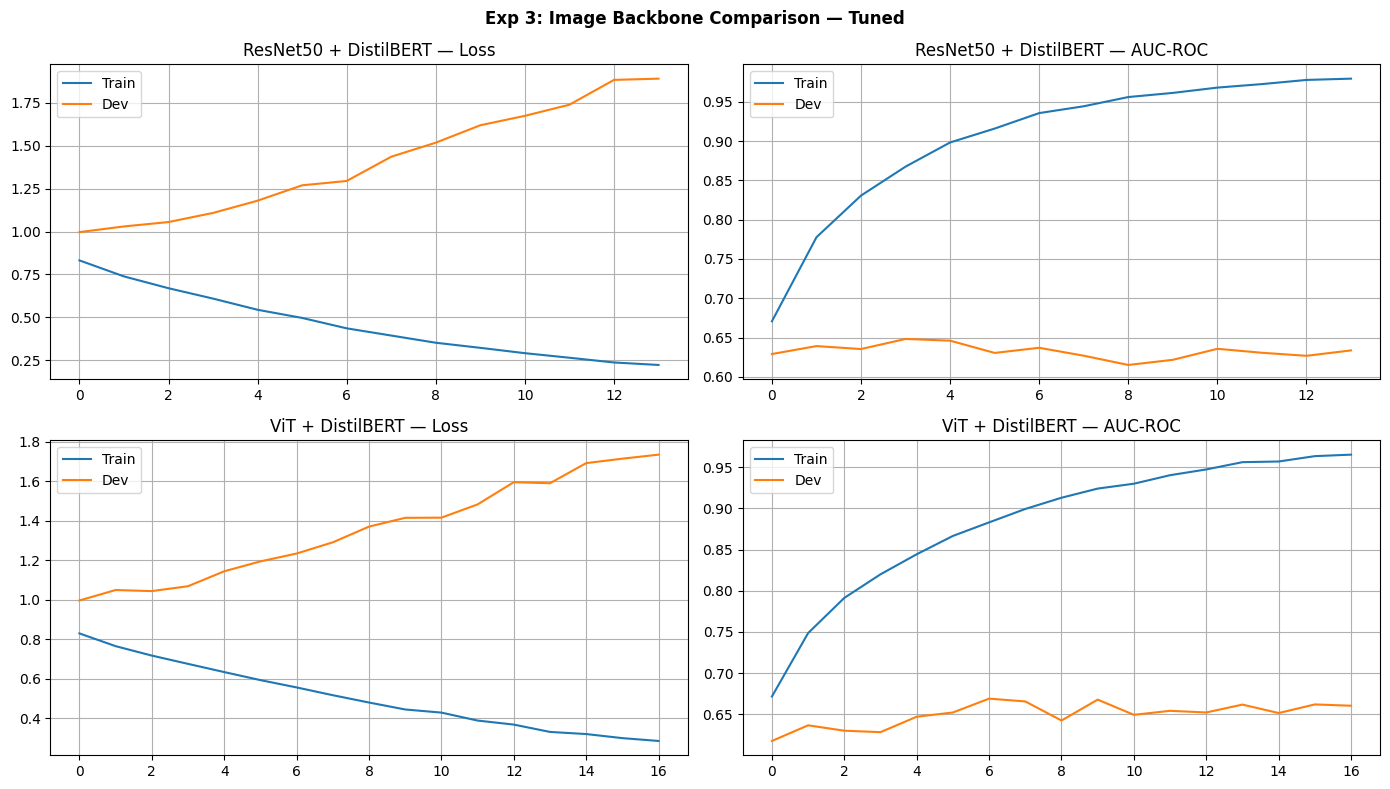

In [18]:
os.makedirs(ROOT / 'outputs', exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
labels = {'resnet50': 'ResNet50 + DistilBERT', 'vit': 'ViT + DistilBERT'}

for row, img_key in enumerate(['resnet50', 'vit']):
    h = histories[img_key]
    axes[row,0].plot(h['train_loss'], label='Train'); axes[row,0].plot(h['dev_loss'], label='Dev')
    axes[row,0].set_title(f'{labels[img_key]} — Loss'); axes[row,0].legend(); axes[row,0].grid(True)
    axes[row,1].plot(h['train_auc'],  label='Train'); axes[row,1].plot(h['dev_auc'],  label='Dev')
    axes[row,1].set_title(f'{labels[img_key]} — AUC-ROC'); axes[row,1].legend(); axes[row,1].grid(True)

plt.suptitle('Exp 3: Image Backbone Comparison — Tuned', fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'outputs/03_training_curves.png', dpi=150)
plt.show()

## 8. Results & Backbone Selection

In [19]:
print('=' * 55)
print('EXP 3 — Image Backbone Comparison | Dev Set')
print('=' * 55)
for img_key in ['resnet50', 'vit']:
    r = results[img_key]
    print(f'  {img_key.upper()+" + DistilBERT":30s}: AUC = {r["dev_auc_roc"]:.4f}  Acc = {r["dev_accuracy"]:.4f}')

best_backbone = max(results, key=lambda k: results[k]['dev_auc_roc'])
print(f'\n-> Best image backbone: {best_backbone.upper()} (AUC = {results[best_backbone]["dev_auc_roc"]:.4f})')

EXP 3 — Image Backbone Comparison | Dev Set
  RESNET50 + DistilBERT         : AUC = 0.6482  Acc = 0.5860
  VIT + DistilBERT              : AUC = 0.6690  Acc = 0.5800

-> Best image backbone: VIT (AUC = 0.6690)


## 9. Save Models & Results

In [20]:
os.makedirs(ROOT / 'models', exist_ok=True)
os.makedirs(ROOT / 'results', exist_ok=True)

for img_key in ['resnet50', 'vit']:
    torch.save(trained_models[img_key].state_dict(),
               ROOT / f'models/03_{img_key}_distilbert_concat_mlp.pt')

exp3_out = {
    'experiment': '03_ImageBackboneSelection',
    'pipeline': 'img_proj + text_proj -> concat -> MLP',
    'text_backbone': 'DistilBERT CLS (768-dim)',
    'results': results,
    'best_image_backbone': best_backbone,
    'best_img_dim': IMG_DIMS[best_backbone]
}
with open(ROOT / 'results/exp3.json', 'w') as f:
    json.dump(exp3_out, f, indent=2)

print('Saved:')
for img_key in ['resnet50', 'vit']:
    print(f'  models/03_{img_key}_distilbert_concat_mlp.pt')
print('  results/exp3.json')
print(json.dumps(exp3_out, indent=2))

Saved:
  models/03_resnet50_distilbert_concat_mlp.pt
  models/03_vit_distilbert_concat_mlp.pt
  results/exp3.json
{
  "experiment": "03_ImageBackboneSelection",
  "pipeline": "img_proj + text_proj -> concat -> MLP",
  "text_backbone": "DistilBERT CLS (768-dim)",
  "results": {
    "resnet50": {
      "dev_auc_roc": 0.6482,
      "dev_accuracy": 0.586
    },
    "vit": {
      "dev_auc_roc": 0.669,
      "dev_accuracy": 0.58
    }
  },
  "best_image_backbone": "vit",
  "best_img_dim": 768
}
